# 6.2 Non-Uniform Random Numbers

In [1]:
import sys
sys.path.insert(0, "../")
from plotting import *
setup_plotting()
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

Uniform random numbers are useful, but usually we want to generate random numbers from some non-uniform distribution. There are a few ways to do this depending on the distribution.

## Inverse CDF Transformation

The most generic method (but not necessarily the simplest) uses the inverse of the cumulative distribution function of the distribution.

Suppose we want to draw samples from a distribution with density $f$ and cumulative distribution function $F(x) = \int_{-\infty}^x f(t)\,dt$. Then we can do the following:

1. Draw $U\sim \text{Unif}(0, 1)$ using any suitable PRNG.
2. Let $X = F^{-1}(U)$. Then $X$ is distributed according to $f$.

Of course this method requires the inversion of the CDF, which is usually not possible. However, it works well for the Exponential($\lambda$) distribution, where $\lambda$ is the mean. Here, we have that

$$f(x) = \frac{1}{\lambda}e^{-x/\lambda}$$

and

$$F(x) = 1-e^{-x/\lambda}.$$

Therefore, the inverse of the CDF is

$$F^{-1}(u) = -\lambda\log(1-u).$$

First we can draw our uniform random variables.

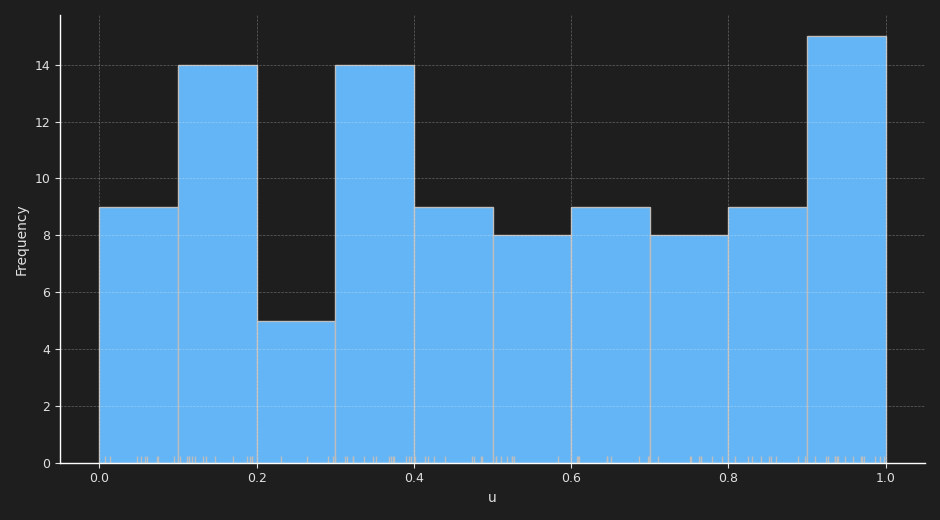

In [2]:
rng = np.random.default_rng(20171204)
u = rng.uniform(0, 1, size=100)

fig, ax = plt.subplots(figsize=FIGSIZE_DEFAULT)
ax.hist(u, bins=np.linspace(0, 1, 11), color=C['blue'], edgecolor=C['grey'])
ax.plot(u, np.zeros_like(u), '|', color=C['grey'], markersize=10)
ax.set_xlabel('u')
ax.set_ylabel('Frequency')
plt.tight_layout()

Then we can apply the inverse CDF.

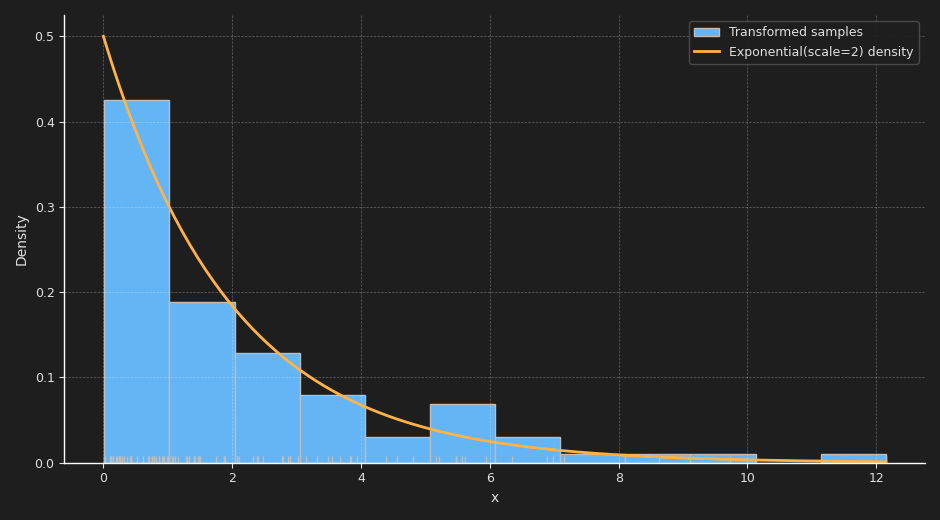

In [3]:
lam = 2.0  # Exponential with mean 2
x = -lam * np.log(1 - u)

fig, ax = plt.subplots(figsize=FIGSIZE_DEFAULT)
ax.hist(x, bins=12, density=True, color=C['blue'], edgecolor=C['grey'],
        label='Transformed samples')
ax.plot(x, np.zeros_like(x), '|', color=C['grey'], markersize=10)
grid = np.linspace(0, x.max(), 200)
# scipy parameterizes the Exponential by scale = mean = lambda (not rate).
ax.plot(grid, stats.expon.pdf(grid, scale=lam), color=C['orange'],
        label=f'Exponential(scale={lam:.0f}) density')
ax.set_xlabel('x')
ax.set_ylabel('Density')
ax.legend(loc='upper right')
plt.tight_layout()

The problem with this method is that inverting the CDF is usually a difficult process and so other methods will be needed to generate other random variables.

## Other Transformations

The inverse of the CDF is not the only function that we can use to transform uniform random variables into random variables with other distributions. Here are some common transformations.

To generate **Normal** random variables, we can

1. Generate $U_1, U_2\sim\text{Unif}(0, 1)$ using a standard PRNG.
2. Set

    $$\begin{aligned}
    Z_1 & = \sqrt{-2\log U_1}\cos(2\pi\, U_2)\\
    Z_2 & = \sqrt{-2\log U_1}\sin(2\pi\, U_2)
    \end{aligned}$$

    Then $Z_1$ and $Z_2$ are distributed independent $N(0, 1)$.

What about multivariate Normal random variables with arbitrary covariance structure? This can be done by applying an affine transformation to independent Normals.

If we want to generate $X\sim\mathcal{N}(\mu, \Sigma)$, we can

1. Generate $Z\sim\mathcal{N}(0, I)$ where $I$ is the identity matrix;
2. Let $\Sigma = LL^\prime$ be the Cholesky decomposition of $\Sigma$;
3. Let $X = \mu + LZ$. Then $X\sim\mathcal{N}(\mu, \Sigma)$.

In reality, you will not need to apply *any* of the transformations described above because almost any worthwhile analytical software system will have these generators built in, if not carved in stone. However, once in a while, it's still nice to know how things work.